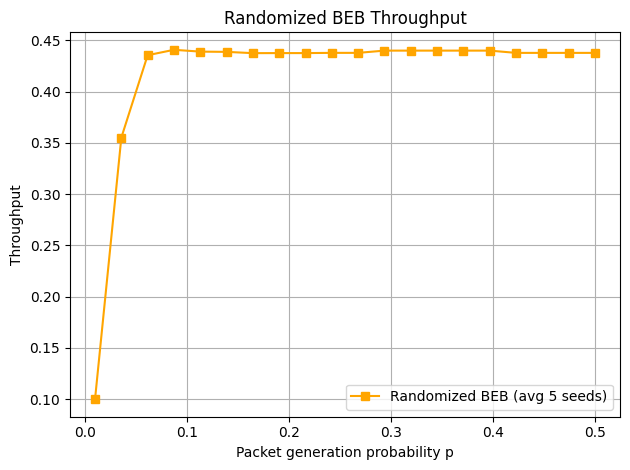

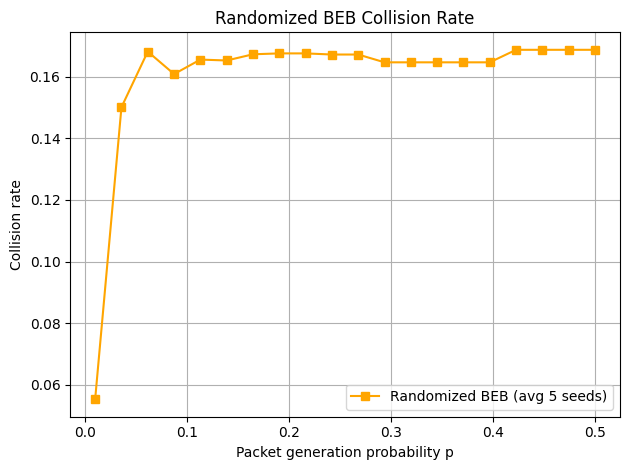

=== Randomized BEB KPI Summary ===
     p |   Throughput | Collision Rate
--------------------------------------
  0.01 |       0.0999 |         0.0553
  0.04 |       0.3551 |         0.1501
  0.06 |       0.4355 |         0.1682
  0.09 |       0.4407 |         0.1609
  0.11 |       0.4390 |         0.1656
  0.14 |       0.4387 |         0.1653
  0.16 |       0.4375 |         0.1673
  0.19 |       0.4375 |         0.1676
  0.22 |       0.4375 |         0.1676
  0.24 |       0.4378 |         0.1672
  0.27 |       0.4378 |         0.1672
  0.29 |       0.4399 |         0.1647
  0.32 |       0.4399 |         0.1647
  0.35 |       0.4399 |         0.1647
  0.37 |       0.4399 |         0.1647
  0.40 |       0.4399 |         0.1647
  0.42 |       0.4377 |         0.1687
  0.45 |       0.4377 |         0.1687
  0.47 |       0.4377 |         0.1687
  0.50 |       0.4377 |         0.1687


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
N = 10
T = 50000
CW_MIN = 4
CW_MAX = 1024
NUM_SEEDS = 5
p_values = np.linspace(0.01, 0.5, 20)
class Node:

    def __init__(self, p, node_id, rng):
        self.p = p
        self.node_id = node_id
        self.rng = rng

        self.arrival_interval = max(1, int(round(1 / p)))

        self.queue = 0
        self.cw = CW_MIN
        self.backoff = self.rng.integers(0, self.cw)

    def arrival(self, slot):
        if (slot + self.node_id) % self.arrival_interval == 0:
            self.queue += 1

    def decrement_backoff(self):
        if self.queue > 0 and self.backoff > 0:
            self.backoff -= 1

    def ready(self):
        return self.queue > 0 and self.backoff == 0

    def success(self):
        self.queue -= 1
        self.cw = CW_MIN
        self.backoff = self.rng.integers(0, self.cw)

    def collision(self):
        self.cw = min(self.cw * 2, CW_MAX)
        self.backoff = self.rng.integers(0, self.cw)

def run_simulation(p, seed):
    rng = np.random.default_rng(seed)
    nodes = [Node(p, i, rng) for i in range(N)]
    successes = 0
    collisions = 0
    for slot in range(T):

        for node in nodes:
            node.arrival(slot)

        for node in nodes:
            node.decrement_backoff()

        transmitters = [node for node in nodes if node.ready()]

        if len(transmitters) == 1:
            successes += 1
            transmitters[0].success()

        elif len(transmitters) > 1:
            collisions += 1
            for node in transmitters:
                node.collision()

    throughput = successes / T
    collision_rate = collisions / T

    return throughput, collision_rate

rand_throughputs = []
rand_collisions = []
for p in p_values:
    thr_runs = []
    col_runs = []

    for seed in range(NUM_SEEDS):
        thr, col = run_simulation(p, seed)
        thr_runs.append(thr)
        col_runs.append(col)

    rand_throughputs.append(np.mean(thr_runs))
    rand_collisions.append(np.mean(col_runs))

plt.figure()
plt.plot(p_values, rand_throughputs, label=f"Randomized BEB (avg {NUM_SEEDS} seeds)",
         linestyle='-', marker='s', color='orange')
plt.xlabel("Packet generation probability p")
plt.ylabel("Throughput")
plt.title("Randomized BEB Throughput")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(p_values, rand_collisions, label=f"Randomized BEB (avg {NUM_SEEDS} seeds)",
         linestyle='-', marker='s', color='orange')
plt.xlabel("Packet generation probability p")
plt.ylabel("Collision rate")
plt.title("Randomized BEB Collision Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print("=== Randomized BEB KPI Summary ===")
print(f"{'p':>6} | {'Throughput':>12} | {'Collision Rate':>14}")
print("-" * 38)
for i, p in enumerate(p_values):
    print(f"{p:>6.2f} | {rand_throughputs[i]:>12.4f} | {rand_collisions[i]:>14.4f}")

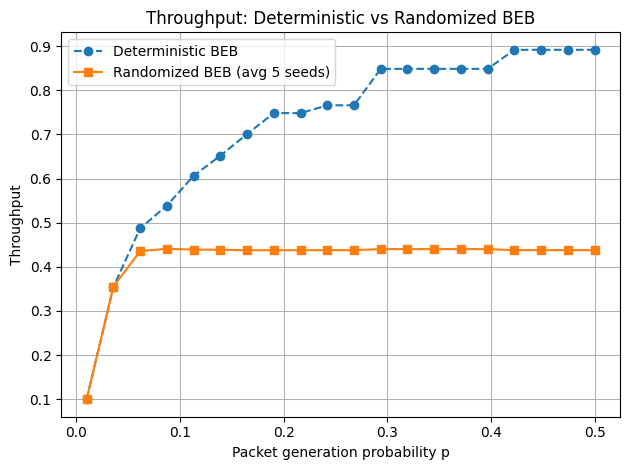

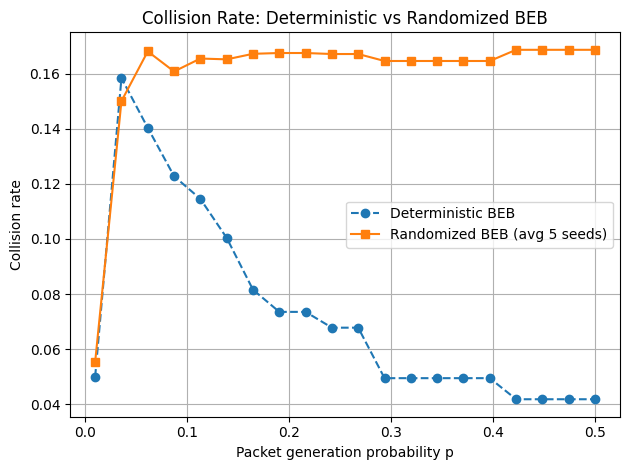

=== KPI Summary ===
     p |    Det Thr |   Rand Thr |    Det Col |   Rand Col
--------------------------------------------------------
  0.01 |     0.0999 |     0.0999 |     0.0500 |     0.0553
  0.04 |     0.3541 |     0.3551 |     0.1585 |     0.1501
  0.06 |     0.4872 |     0.4355 |     0.1404 |     0.1682
  0.09 |     0.5386 |     0.4407 |     0.1228 |     0.1609
  0.11 |     0.6061 |     0.4390 |     0.1146 |     0.1656
  0.14 |     0.6518 |     0.4387 |     0.1004 |     0.1653
  0.16 |     0.7007 |     0.4375 |     0.0816 |     0.1673
  0.19 |     0.7482 |     0.4375 |     0.0735 |     0.1676
  0.22 |     0.7482 |     0.4375 |     0.0735 |     0.1676
  0.24 |     0.7659 |     0.4378 |     0.0678 |     0.1672
  0.27 |     0.7659 |     0.4378 |     0.0678 |     0.1672
  0.29 |     0.8485 |     0.4399 |     0.0494 |     0.1647
  0.32 |     0.8485 |     0.4399 |     0.0494 |     0.1647
  0.35 |     0.8485 |     0.4399 |     0.0494 |     0.1647
  0.37 |     0.8485 |     0.4399 |    

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
N = 10
T = 50000
CW_MIN = 4
CW_MAX = 1024
NUM_SEEDS = 5
p_values = np.linspace(0.01, 0.5, 20)
class Node:

    def __init__(self, p, node_id, rng):
        self.p = p
        self.node_id = node_id
        self.rng = rng

        self.arrival_interval = max(1, int(round(1 / p)))

        self.queue = 0
        self.cw = CW_MIN

        self.backoff = self.rng.integers(0, self.cw)

    def arrival(self, slot):
        if (slot + self.node_id) % self.arrival_interval == 0:
            self.queue += 1

    def decrement_backoff(self):
        if self.queue > 0 and self.backoff > 0:
            self.backoff -= 1

    def ready(self):
        return self.queue > 0 and self.backoff == 0

    def success(self):
        self.queue -= 1
        self.cw = CW_MIN
        # Random backoff from [0, CW_MIN - 1]
        self.backoff = self.rng.integers(0, self.cw)

    def collision(self):
        self.cw = min(self.cw * 2, CW_MAX)
        # Random backoff from [0, new_CW - 1]
        self.backoff = self.rng.integers(0, self.cw)


def run_simulation(p, seed):

    rng = np.random.default_rng(seed)
    nodes = [Node(p, i, rng) for i in range(N)]

    successes = 0
    collisions = 0

    for slot in range(T):

        for node in nodes:
            node.arrival(slot)

        for node in nodes:
            node.decrement_backoff()

        transmitters = [node for node in nodes if node.ready()]

        if len(transmitters) == 1:
            successes += 1
            transmitters[0].success()

        elif len(transmitters) > 1:
            collisions += 1
            for node in transmitters:
                node.collision()

    throughput = successes / T
    collision_rate = collisions / T
    return throughput, collision_rate

rand_throughputs = []
rand_collisions = []

for p in p_values:
    thr_runs = []
    col_runs = []

    for seed in range(NUM_SEEDS):
        thr, col = run_simulation(p, seed)
        thr_runs.append(thr)
        col_runs.append(col)

    rand_throughputs.append(np.mean(thr_runs))
    rand_collisions.append(np.mean(col_runs))

class DetNode:
    def __init__(self, p, node_id):
        self.p = p
        self.node_id = node_id
        self.arrival_interval = max(1, int(round(1 / p)))
        self.queue = 0
        self.cw = CW_MIN
        self.backoff = (CW_MIN // 2 + node_id) % CW_MIN

    def arrival(self, slot):
        if (slot + self.node_id) % self.arrival_interval == 0:
            self.queue += 1

    def decrement_backoff(self):
        if self.queue > 0 and self.backoff > 0:
            self.backoff -= 1

    def ready(self):
        return self.queue > 0 and self.backoff == 0

    def success(self):
        self.queue -= 1
        self.cw = CW_MIN
        self.backoff = (self.cw // 2 + self.node_id) % self.cw

    def collision(self):
        self.cw = min(self.cw * 2, CW_MAX)
        self.backoff = (self.cw // 2 + self.node_id) % self.cw

def run_det_simulation(p):
    nodes = [DetNode(p, i) for i in range(N)]
    successes = 0
    collisions = 0
    for slot in range(T):
        for node in nodes:
            node.arrival(slot)
        for node in nodes:
            node.decrement_backoff()
        transmitters = [node for node in nodes if node.ready()]
        if len(transmitters) == 1:
            successes += 1
            transmitters[0].success()
        elif len(transmitters) > 1:
            collisions += 1
            for node in transmitters:
                node.collision()
    return successes / T, collisions / T

det_throughputs = []
det_collisions = []
for p in p_values:
    thr, col = run_det_simulation(p)
    det_throughputs.append(thr)
    det_collisions.append(col)

plt.figure()
plt.plot(p_values, det_throughputs, label="Deterministic BEB", linestyle='--', marker='o')
plt.plot(p_values, rand_throughputs, label=f"Randomized BEB (avg {NUM_SEEDS} seeds)", linestyle='-', marker='s')
plt.xlabel("Packet generation probability p")
plt.ylabel("Throughput")
plt.title("Throughput: Deterministic vs Randomized BEB")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(p_values, det_collisions, label="Deterministic BEB", linestyle='--', marker='o')
plt.plot(p_values, rand_collisions, label=f"Randomized BEB (avg {NUM_SEEDS} seeds)", linestyle='-', marker='s')
plt.xlabel("Packet generation probability p")
plt.ylabel("Collision rate")
plt.title("Collision Rate: Deterministic vs Randomized BEB")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("=== KPI Summary ===")
print(f"{'p':>6} | {'Det Thr':>10} | {'Rand Thr':>10} | {'Det Col':>10} | {'Rand Col':>10}")
print("-" * 56)
for i, p in enumerate(p_values):
    print(f"{p:>6.2f} | {det_throughputs[i]:>10.4f} | {rand_throughputs[i]:>10.4f} | "
          f"{det_collisions[i]:>10.4f} | {rand_collisions[i]:>10.4f}")

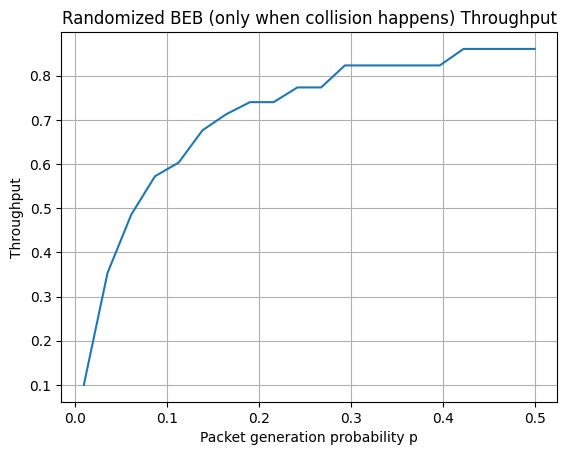

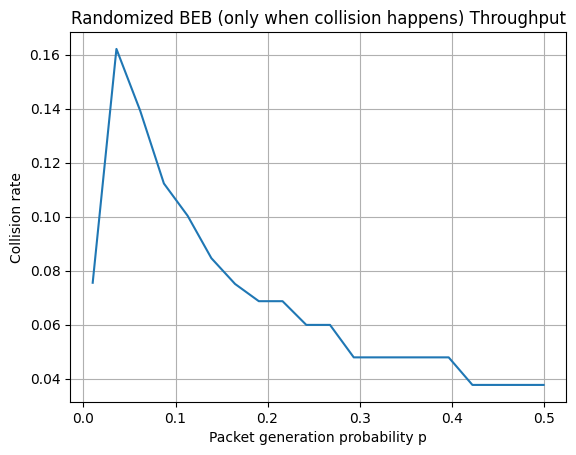

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
N = 10
T = 50000
CW_MIN = 4
CW_MAX = 1024
NUM_RUNS = 5
p_values = np.linspace(0.01,0.5,20)
class Node:

    def __init__(self,p,node_id):

        self.p = p
        self.node_id = node_id

        # Same deterministic arrivals
        self.arrival_interval = max(1,int(round(1/p)))

        self.queue = 0
        self.cw = CW_MIN

        # SAME deterministic start
        self.backoff = (CW_MIN//2 + node_id) % CW_MIN

    def arrival(self,slot):

        if (slot + self.node_id) % self.arrival_interval == 0:
            self.queue += 1

    def decrement_backoff(self):

        if self.queue > 0 and self.backoff > 0:
            self.backoff -= 1

    def ready(self):

        return self.queue > 0 and self.backoff == 0

    def success(self):

        self.queue -= 1

        # reset CW
        self.cw = CW_MIN

        # KEEP deterministic reset
        self.backoff = (self.cw//2 + self.node_id) % self.cw

    def collision(self):

        # BEB growth
        self.cw = min(self.cw*2,CW_MAX)

        # RANDOM ONLY HERE
        self.backoff = np.random.randint(0,self.cw)

def run_simulation(p,seed):

    np.random.seed(seed)

    nodes = [Node(p,i) for i in range(N)]

    successes = 0
    collisions = 0

    for slot in range(T):

        for node in nodes:
            node.arrival(slot)

        for node in nodes:
            node.decrement_backoff()

        transmitters = [node for node in nodes if node.ready()]

        if len(transmitters) == 1:

            successes += 1
            transmitters[0].success()

        elif len(transmitters) > 1:

            collisions += 1

            for node in transmitters:
                node.collision()

    return successes/T, collisions/T

throughputs = []
collisions = []

for p in p_values:

    thr_runs = []
    col_runs = []

    for run in range(NUM_RUNS):

        thr,col = run_simulation(p,seed=run)

        thr_runs.append(thr)
        col_runs.append(col)

    throughputs.append(np.mean(thr_runs))
    collisions.append(np.mean(col_runs))
plt.figure()
plt.plot(p_values,throughputs)
plt.xlabel("Packet generation probability p")
plt.ylabel("Throughput")
plt.title("Randomized BEB (only when collision happens) Throughput")
plt.grid()
plt.show()
plt.figure()
plt.plot(p_values,collisions)
plt.xlabel("Packet generation probability p")
plt.ylabel("Collision rate")
plt.title("Randomized BEB (only when collision happens) Throughput")
plt.grid()
plt.show()